# Session 5-peaks: Using the FINDPEAKS Function

In [1]:
# Importing Functions

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Naming empty lists

In [4]:
time = []
absorption = []

In [5]:
# Load absorption data from CSV file

In [6]:
with open('data/pulse_data.csv', 'r') as f:
    next(f)
    
    for line in f:
        t, p = line.strip().split(',')
        time.append(float(t))
        absorption.append(float(p))

In [7]:
# Convert to numpy

In [8]:
time = np.array(time)
absorption = np.array(absorption)

In [9]:
# Plot pulse data over time using matplotlib

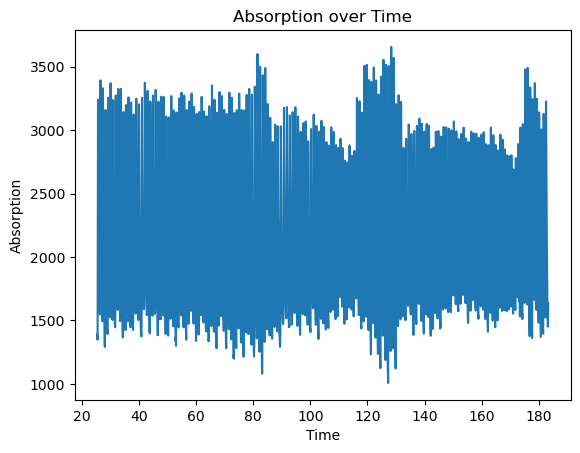

In [10]:
plt.plot(time, absorption)
plt.xlabel("Time")
plt.ylabel("Absorption")
plt.title("Absorption over Time")
plt.show()

In [11]:
# Peak Detection

##Peaks correspond to heart beats and are identified as local maxima in the absorption signal.

##Using NumPy arrays allows efficient vectorized comparison of neighboring values to detect peaks.

##A minimum time separation between consecutive peaks is enforced to ensure that detected peaks represent physiological heart beats rather than noise.

In [12]:
peak_indices = np.where(
    (absorption[1:-1] > absorption[:-2]) &
    (absorption[1:-1] > absorption[2:])
)[0] + 1

In [13]:
# Applying Time Separation

In [14]:
peaks = time[peak_indices]

filtered_peaks = [peaks[0]]

for t in peaks[1:]:
    if t - filtered_peaks[-1] > 0.3:
        filtered_peaks.append(t)

peaks = np.array(filtered_peaks)

In [15]:
print(len(peaks))

182


In [16]:
print("Number of peaks detected:", len(peaks))

Number of peaks detected: 182


In [17]:
# Time Difference Between Peaks

# We compute the time difference between consecutive peaks.

In [18]:
delta_t = np.diff(peaks)

In [19]:
# Heart Rate Calculation

#The heart rate is calculated using:

# H = 60 / ΔT

# where ΔT is the time between peaks.

In [20]:
heart_rate = 60 / delta_t

In [21]:
# Heart Rate Plot

# We plot the heart rate over time.

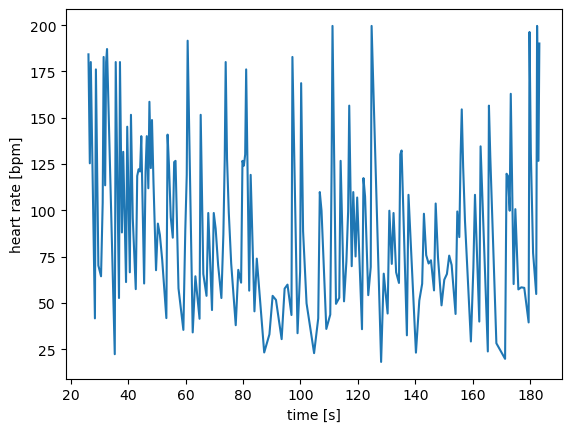

In [22]:
plt.plot(peaks[1:], heart_rate)
plt.xlabel("time [s]")
plt.ylabel("heart rate [bpm]")
plt.show()

In [2]:
# Data Loading

In [3]:
import pandas as pd

data = pd.read_csv("data/pulse_data.csv")

time = data.iloc[:, 0]
absorption = data.iloc[:, 1]

In [4]:
# Cleaning Data

In [5]:
absorption = pd.to_numeric(absorption, errors='coerce')
time = pd.to_numeric(time, errors='coerce')

# remove NaNs
valid = ~(absorption.isna() | time.isna())
time = time[valid]
absorption = absorption[valid]

In [ ]:
# Plotting Signal

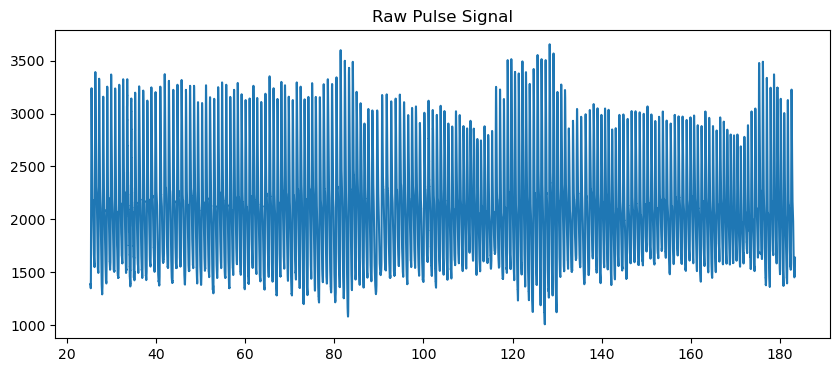

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(time, absorption)
plt.title("Raw Pulse Signal")
plt.show()

In [ ]:
# Peak Detection

In [7]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(
    absorption,
    distance=20,     # spacing between beats
    prominence=0.2   # removes noise peaks
)

In [ ]:
# Plot Peaks

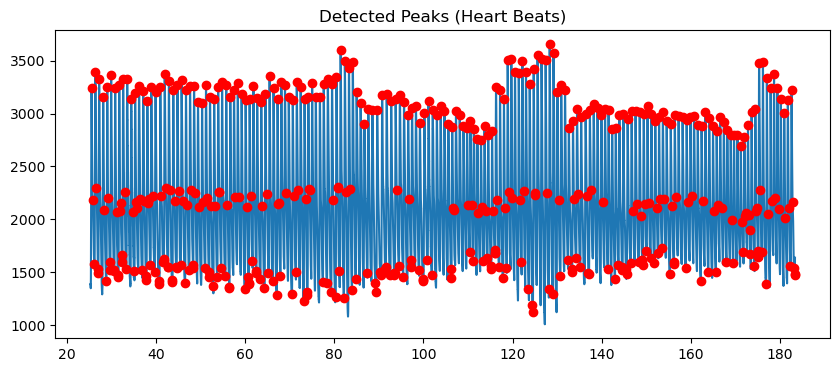

In [8]:
plt.figure(figsize=(10,4))
plt.plot(time, absorption)
plt.plot(time.iloc[peaks], absorption.iloc[peaks], "ro")
plt.title("Detected Peaks (Heart Beats)")
plt.show()

In [ ]:
Heart Rate

In [9]:
duration = time.iloc[-1] - time.iloc[0]
heart_rate = (len(peaks) / duration) * 60

print(f"Heart Rate: {heart_rate:.2f} BPM")

Heart Rate: 169.37 BPM


In [ ]:
#The synthetic signal and lack of proper filtering led to detection of many local maxima caused by noise rather than true heartbeats. Additionally, without constraints such as minimum distance and prominence, the algorithm identified insignificant fluctuations as peaks.